In [1]:
!pip install torchmetrics

In [2]:
pip install torch-fidelity

Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install torchsummary

Note: you may need to restart the kernel to use updated packages.


In [4]:
import torch
from torch import nn
from torch.nn import functional as F 
import torchvision
from torchsummary import summary
from torchvision import transforms
from torch.utils.data import DataLoader
import numpy as np
import math
from torch.optim import Adam
from matplotlib import pyplot as plt

In [5]:
IMG_SIZE = 32
BATCH_SIZE = 64
T = 200
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

Using device: cuda


In [6]:
def beta_scheduler(timesteps, start=0.0001, end=0.02):
    return torch.linspace(start, end, timesteps)

betas = beta_scheduler(timesteps=T)
alphas = 1. - betas
alphas_cumprod = torch.cumprod(alphas, axis=0)
alphas_cumprod_prev = F.pad(alphas_cumprod[:-1], (1, 0), value=1.0)


In [7]:
sqrt_recip_alphas = torch.sqrt(1.0 / alphas)
sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1. - alphas_cumprod)
posterior_variance = betas * (1. - alphas_cumprod_prev) / (1. - alphas_cumprod)

In [8]:
def get_index(vals, t, x_shape):
    """Returns the correct diffusion value for the specific timestep t in the batch."""
    batch_size = t.shape[0]  
    out = vals.to(t.device).gather(-1, t) 
    
    return out.reshape(batch_size, *((1,) * (len(x_shape) - 1)))

In [9]:
def forward_diffusion(x_0, t, device=device):
    """Takes an image x_0 and adds noise up to timestep t."""
    noise = torch.randn_like(x_0)
    sqrt_alphas_cumprod_t = get_index(sqrt_alphas_cumprod, t, x_0.shape)
    sqrt_one_minus_alphas_cumprod_t = get_index(sqrt_one_minus_alphas_cumprod, t, x_0.shape)
    
    mean = sqrt_alphas_cumprod_t.to(device) * x_0.to(device)
    variance = sqrt_one_minus_alphas_cumprod_t.to(device) * noise.to(device)
    
    noisy_image = mean + variance
    return noisy_image, noise.to(device)

In [10]:
def load_transformed_dataset():
    data_transforms = [
        transforms.Resize((IMG_SIZE, IMG_SIZE)), 
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Lambda(lambda t: (t * 2) - 1) 
    ]
    data_transform = transforms.Compose(data_transforms)

    train_data = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=data_transform)
    test_data = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=data_transform)
    
    return torch.utils.data.ConcatDataset([train_data, test_data])

data = load_transformed_dataset()
dataloader = DataLoader(data, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

In [11]:
class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        embeddings = math.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings

In [12]:
class SelfAttention(nn.Module):
    def __init__(self, channels):
        super(SelfAttention, self).__init__()
        self.channels = channels
        self.mha = nn.MultiheadAttention(embed_dim=channels, num_heads=4, batch_first=True)
        self.ln = nn.LayerNorm([channels])

    def forward(self, x):
        # x shape: (B, C, H, W)
        B, C, H, W = x.shape
        x_reshaped = x.view(B, C, -1).permute(0, 2, 1) 
        
        x_ln = self.ln(x_reshaped)
        attention_value, _ = self.mha(x_ln, x_ln, x_ln)
        
        out = (x_reshaped + attention_value).permute(0, 2, 1).view(B, C, H, W)
        return out

In [13]:


class MADUNet(nn.Module):
    def __init__(self, out_channels=3, time_emb_dim=256):
        super(MADUNet, self).__init__()

        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim),
            nn.ReLU()
        )
        
        self.time_emb1 = nn.Linear(time_emb_dim, 64)
        self.time_emb2 = nn.Linear(time_emb_dim, 128)
        self.time_emb3 = nn.Linear(time_emb_dim, 256)
        self.time_emb4 = nn.Linear(time_emb_dim, 512)
        self.time_emb5 = nn.Linear(time_emb_dim, 1024)

        # Downward Path (Using GroupNorm instead of BatchNorm)
        self.l1_1 = nn.Conv2d(3,64,3,1,1)
        self.gn1_1 = nn.GroupNorm(8, 64)
        self.l1_2 = nn.Conv2d(64,64,3,1,1)
        self.gn1_2 = nn.GroupNorm(8, 64)

        self.l2_1 = nn.Conv2d(64,128,3,1,1)
        self.gn2_1 = nn.GroupNorm(8, 128)
        self.l2_2 = nn.Conv2d(128,128,3,1,1)
        self.gn2_2 = nn.GroupNorm(8, 128)

        self.l3_1 = nn.Conv2d(128,256,3,1,1)
        self.gn3_1 = nn.GroupNorm(8, 256)
        self.l3_2 = nn.Conv2d(256,256,3,1,1)
        self.gn3_2 = nn.GroupNorm(8, 256)

        self.l4_1 = nn.Conv2d(256,512,3,1,1)
        self.gn4_1 = nn.GroupNorm(8, 512)
        self.l4_2 = nn.Conv2d(512,512,3,1,1)
        self.gn4_2 = nn.GroupNorm(8, 512)

        # ottleneck (With Self-Attention)
        self.l5_1 = nn.Conv2d(512,1024,3,1,1)
        self.gn5_1 = nn.GroupNorm(8, 1024)
        self.attn = SelfAttention(1024) 
        self.l5_2 = nn.Conv2d(1024,1024,3,1,1)
        self.gn5_2 = nn.GroupNorm(8, 1024)

        self.pool = nn.MaxPool2d(2,2)
        self.relu = nn.ReLU()

        # Upward Path
        self.up_conv1 = nn.ConvTranspose2d(1024,512,2,2)
        self.l_4  = nn.Conv2d(1024,512,3,1,1)
        self.gn4  = nn.GroupNorm(8, 512)
        self.l_42 = nn.Conv2d(512,512,3,1,1)
        self.gn42 = nn.GroupNorm(8, 512)
        
        self.up_conv2 = nn.ConvTranspose2d(512,256,2,2)
        self.l_3  = nn.Conv2d(512,256,3,1,1)
        self.gn3  = nn.GroupNorm(8, 256)
        self.l_32 = nn.Conv2d(256,256,3,1,1)
        self.gn32 = nn.GroupNorm(8, 256)
        
        self.up_conv3 = nn.ConvTranspose2d(256,128,2,2)
        self.l_2  = nn.Conv2d(256,128,3,1,1)
        self.gn2  = nn.GroupNorm(8, 128)
        self.l_22 = nn.Conv2d(128,128,3,1,1)
        self.gn22 = nn.GroupNorm(8, 128)
        
        self.up_conv4 = nn.ConvTranspose2d(128,64,2,2)
        self.l_1  = nn.Conv2d(128,64,3,1,1)
        self.gn1  = nn.GroupNorm(8, 64)
        self.l_12 = nn.Conv2d(64,64,3,1,1)
        self.gn12 = nn.GroupNorm(8, 64)

        self.fin = nn.Conv2d(64, out_channels, 1, 1)

    def forward(self, x, t): 
        t_emb = self.time_mlp(t)
        
        # Block 1
        x = self.l1_1(x)
        x = self.gn1_1(x)
        x = self.relu(x)
        x = x + self.time_emb1(t_emb).unsqueeze(-1).unsqueeze(-1)
        x = self.l1_2(x)
        x = self.gn1_2(x)
        x = self.relu(x)
        x1 = x
        x = self.pool(x)

        # Block 2
        x = self.l2_1(x)
        x = self.gn2_1(x)
        x = self.relu(x)
        x = x + self.time_emb2(t_emb).unsqueeze(-1).unsqueeze(-1)
        x = self.l2_2(x)
        x = self.gn2_2(x)
        x = self.relu(x)
        x2 = x
        x = self.pool(x)

        # Block 3
        x = self.l3_1(x)
        x = self.gn3_1(x)
        x = self.relu(x)
        x = x + self.time_emb3(t_emb).unsqueeze(-1).unsqueeze(-1)
        x = self.l3_2(x)
        x = self.gn3_2(x)
        x = self.relu(x)
        x3 = x
        x = self.pool(x)

        # Block 4
        x = self.l4_1(x)
        x = self.gn4_1(x)
        x = self.relu(x)
        x = x + self.time_emb4(t_emb).unsqueeze(-1).unsqueeze(-1)
        x = self.l4_2(x)
        x = self.gn4_2(x)
        x = self.relu(x)
        x4 = x
        x = self.pool(x)

        # Bottleneck
        x = self.l5_1(x)
        x = self.gn5_1(x)
        x = self.relu(x)
        x = x + self.time_emb5(t_emb).unsqueeze(-1).unsqueeze(-1)
        x = self.attn(x) 
        x = self.l5_2(x)
        x = self.gn5_2(x)
        x = self.relu(x)

        # Up 1
        x = self.up_conv1(x)
        x = torch.cat([x, x4], dim=1)
        x = self.l_4(x)
        x = self.gn4(x)
        x = self.relu(x)
        x = self.l_42(x)
        x = self.gn42(x)
        x = self.relu(x)

        # Up 2
        x = self.up_conv2(x)
        x = torch.cat([x, x3], dim=1)
        x = self.l_3(x)
        x = self.gn3(x)
        x = self.relu(x)
        x = self.l_32(x)
        x = self.gn32(x)
        x = self.relu(x)

        # Up 3
        x = self.up_conv3(x)
        x = torch.cat([x, x2], dim=1)
        x = self.l_2(x)
        x = self.gn2(x)
        x = self.relu(x)
        x = self.l_22(x)
        x = self.gn22(x)
        x = self.relu(x)

        # Up 4
        x = self.up_conv4(x)
        x = torch.cat([x, x1], dim=1)
        x = self.l_1(x)
        x = self.gn1(x)
        x = self.relu(x)
        x = self.l_12(x)
        x = self.gn12(x)
        x = self.relu(x)

        return self.fin(x)


model = MADUNet(out_channels=3).to(device)
print("MADUNet initialized")

MADUNet initialized


In [14]:
class SummaryWrapper(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
        
    def forward(self, x):
        # Generate a dummy timestep tensor of 1s to satisfy the forward pass
        t = torch.ones(x.shape[0], dtype=torch.long, device=x.device)
        return self.model(x, t)


model = MADUNet(out_channels=3).to(device)
print("MADUNet initialized!")
print(summary(SummaryWrapper(model).to(device), (3, 32, 32)))

MADUNet initialized!
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
SinusoidalPositionEmbeddings-1                  [-1, 256]               0
            Linear-2                  [-1, 256]          65,792
              ReLU-3                  [-1, 256]               0
            Conv2d-4           [-1, 64, 32, 32]           1,792
         GroupNorm-5           [-1, 64, 32, 32]             128
              ReLU-6           [-1, 64, 32, 32]               0
            Linear-7                   [-1, 64]          16,448
            Conv2d-8           [-1, 64, 32, 32]          36,928
         GroupNorm-9           [-1, 64, 32, 32]             128
             ReLU-10           [-1, 64, 32, 32]               0
        MaxPool2d-11           [-1, 64, 16, 16]               0
           Conv2d-12          [-1, 128, 16, 16]          73,856
        GroupNorm-13          [-1, 128, 16, 16]             256
        

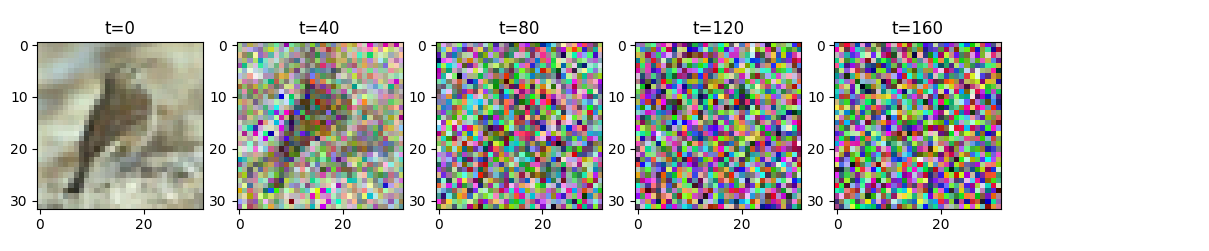

In [15]:
import matplotlib.pyplot as plt

def show_tensor_image(image):
    """Helper to un-normalize and display an image."""
    reverse_transforms = transforms.Compose([
        transforms.Lambda(lambda t: (t + 1) / 2),
        transforms.Lambda(lambda t: t.permute(1, 2, 0)), # CHW to HWC
        transforms.Lambda(lambda t: t * 255.),
        transforms.Lambda(lambda t: t.numpy().astype(np.uint8)),
    ])
    
    
    if len(image.shape) == 4:
        image = image[0, :, :, :] 
    plt.imshow(reverse_transforms(image))

def visualize_forward_process():
    
    image = next(iter(dataloader))[0]
    
    plt.figure(figsize=(15, 3))
    plt.axis("off")
    num_images = 5
    stepsize = int(T / num_images)

    for idx in range(0, T, stepsize):
        t = torch.tensor([idx])
        img, _ = forward_diffusion(image, t, device="cpu")
        plt.subplot(1, num_images + 1, int(idx / stepsize) + 1)
        show_tensor_image(img.cpu())
        plt.title(f"t={idx}")
    plt.show()

visualize_forward_process()

In [16]:
# Initialize Optimizer and Loss
optimizer = Adam(model.parameters(), lr=1e-3)
epochs = 20 

print("Starting Training...")
for epoch in range(epochs):
    epoch_loss = 0.0
    for step, batch in enumerate(dataloader):
        optimizer.zero_grad()
        
        # 1. Get images and put them on GPU
        x_0 = batch[0].to(device)
        
        # 2. Sample random timesteps t uniformly for the whole batch
        t = torch.randint(0, T, (BATCH_SIZE,), device=device).long()
        
        # 3. Add noise to the images (Forward Process)
        x_noisy, actual_noise = forward_diffusion(x_0, t, device)
        
        # 4. Predict the noise using the UNet
        predicted_noise = model(x_noisy, t)
        
        # 5. Calculate Loss (MSE between actual noise and predicted noise)
        loss = F.mse_loss(actual_noise, predicted_noise)
        
        # 6. Backpropagate
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        
        if step % 100 == 0:
            print(f"Epoch [{epoch+1}/{epochs}] | Step [{step}/{len(dataloader)}] | Loss: {loss.item():.4f}")
            
    print(f"--- Epoch {epoch+1} Average Loss: {epoch_loss/len(dataloader):.4f} ---")

Starting Training...


Epoch [1/20] | Step [0/937] | Loss: 1.1922
Epoch [1/20] | Step [100/937] | Loss: 0.1322
Epoch [1/20] | Step [200/937] | Loss: 0.0936
Epoch [1/20] | Step [300/937] | Loss: 0.1136
Epoch [1/20] | Step [400/937] | Loss: 0.0908
Epoch [1/20] | Step [500/937] | Loss: 0.1432
Epoch [1/20] | Step [600/937] | Loss: 0.0899
Epoch [1/20] | Step [700/937] | Loss: 0.1087
Epoch [1/20] | Step [800/937] | Loss: 0.1089
Epoch [1/20] | Step [900/937] | Loss: 0.0843
--- Epoch 1 Average Loss: 0.1165 ---
Epoch [2/20] | Step [0/937] | Loss: 0.1012
Epoch [2/20] | Step [100/937] | Loss: 0.0788
Epoch [2/20] | Step [200/937] | Loss: 0.0935
Epoch [2/20] | Step [300/937] | Loss: 0.0910
Epoch [2/20] | Step [400/937] | Loss: 0.1070
Epoch [2/20] | Step [500/937] | Loss: 0.0994
Epoch [2/20] | Step [600/937] | Loss: 0.1060
Epoch [2/20] | Step [700/937] | Loss: 0.0740
Epoch [2/20] | Step [800/937] | Loss: 0.0756
Epoch [2/20] | Step [900/937] | Loss: 0.0756
--- Epoch 2 Average Loss: 0.0876 ---
Epoch [3/20] | Step [0/937] | 

In [17]:
ddpm_save_path = 'mad_ddpm_cifar10.pth'

torch.save(model.state_dict(), ddpm_save_path)

Generating Images...


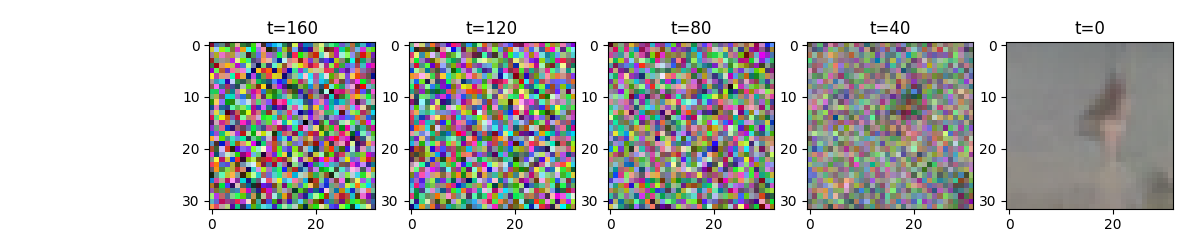

In [18]:
@torch.no_grad()
def sample_timestep(x, t):
    """
    Takes a noisy image x at timestep t, predicts the noise, and takes one step backward.
    """
    betas_t = get_index(betas, t, x.shape).to(device)
    sqrt_one_minus_alphas_cumprod_t = get_index(sqrt_one_minus_alphas_cumprod, t, x.shape).to(device)
    sqrt_recip_alphas_t = get_index(sqrt_recip_alphas, t, x.shape).to(device)
    
    # Model predicts the noise
    predicted_noise = model(x, t)
    
    # Calculate the mean of the previous step
    model_mean = sqrt_recip_alphas_t * (
        x - betas_t * predicted_noise / sqrt_one_minus_alphas_cumprod_t
    )
    
    if t[0].item() == 0:
        return model_mean
    else:
        # Add a little bit of noise back in (Langevin dynamics) for stability
        posterior_variance_t = get_index(posterior_variance, t, x.shape).to(device)
        noise = torch.randn_like(x)
        return model_mean + torch.sqrt(posterior_variance_t) * noise 

@torch.no_grad()
def generate_images(num_images=1):
    # Start with pure random noise
    img = torch.randn((num_images, 3, IMG_SIZE, IMG_SIZE), device=device)
    
    plt.figure(figsize=(15, 3))
    plt.axis("off")
    stepsize = int(T / 5)
    
    print("Generating Images...")
    for i in reversed(range(0, T)):
        t = torch.full((num_images,), i, device=device, dtype=torch.long)
        img = sample_timestep(img, t)
        
        # Plot every few steps to see it denoise!
        if i % stepsize == 0 or i == 0:
            plt.subplot(1, 6, int((T-i)/stepsize) + 1)
            show_tensor_image(img.cpu())
            plt.title(f"t={i}")
    plt.show()

# Run the generator!
generate_images(num_images=3)

In [19]:
import torch
from torchmetrics.image.fid import FrechetInceptionDistance

# 1. Initialize the FID metric
# normalize=True tells the metric to expect float tensors between [0.0, 1.0]
fid = FrechetInceptionDistance(feature=2048, normalize=True).to(device)

@torch.no_grad()
def generate_fake_batch(batch_size):
    """Generates a batch of fake images silently for evaluation."""
    img = torch.randn((batch_size, 3, IMG_SIZE, IMG_SIZE), device=device)
    for i in reversed(range(0, T)):
        t = torch.full((batch_size,), i, device=device, dtype=torch.long)
        img = sample_timestep(img, t)
    return img

def calculate_fid(num_batches=4):
    """
    Calculates FID by comparing real test batches to generated fake batches.
    num_batches defines how many batches of size BATCH_SIZE to evaluate.
    """
    print(f"Calculating FID over {num_batches * BATCH_SIZE} images...")
    
    # We use the test dataloader to get real unseen images
    test_iterator = iter(dataloader)
    
    for i in range(num_batches):
        print(f"Processing batch {i+1}/{num_batches}...")
        
        # Process Real Images 
        try:
            real_images = next(test_iterator)[0].to(device)
        except StopIteration:
            test_iterator = iter(dataloader)
            real_images = next(test_iterator)[0].to(device)
            
        # Our dataloader outputs [-1, 1]. We must scale to [0, 1] for the FID metric
        real_images = (real_images + 1) / 2.0
        real_images = torch.clamp(real_images, 0.0, 1.0)
        
        # Update FID with real images
        fid.update(real_images, real=True)
        
        # --- Process Fake Images ---
        fake_images = generate_fake_batch(BATCH_SIZE)
        
        # Scale generated images from [-1, 1] to [0, 1]
        fake_images = (fake_images + 1) / 2.0
        fake_images = torch.clamp(fake_images, 0.0, 1.0)
        
        # Update FID with fake images
        fid.update(fake_images, real=False)

    # Compute final score
    fid_score = fid.compute()
    print(f"\nFinal FID Score: {fid_score.item():.2f}")

    fid.reset()
    
    return fid_score.item()


calculate_fid(num_batches=32) 

Calculating FID over 2048 images...
Processing batch 1/32...
Processing batch 2/32...
Processing batch 3/32...


Processing batch 4/32...
Processing batch 5/32...
Processing batch 6/32...
Processing batch 7/32...
Processing batch 8/32...
Processing batch 9/32...
Processing batch 10/32...
Processing batch 11/32...
Processing batch 12/32...
Processing batch 13/32...
Processing batch 14/32...
Processing batch 15/32...
Processing batch 16/32...
Processing batch 17/32...
Processing batch 18/32...
Processing batch 19/32...
Processing batch 20/32...
Processing batch 21/32...
Processing batch 22/32...
Processing batch 23/32...
Processing batch 24/32...
Processing batch 25/32...
Processing batch 26/32...
Processing batch 27/32...
Processing batch 28/32...
Processing batch 29/32...
Processing batch 30/32...
Processing batch 31/32...
Processing batch 32/32...

Final FID Score: 81.10


81.10223388671875